## Step 1: Import the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("Libraries imported successfully!")

Libraries imported successfully!


## Example 1: Two-tailed test

**Problem:** A company claims that the average battery life of its phones is **50 hours**. A tester checks 15 phones and records the battery life (in hours). Is the company's claim correct? Use α = 0.05.

- H₀: μ = 50 (claim is correct)
- H₁: μ ≠ 50 (claim is not correct)

In [2]:
# Step 2: Sample data (battery life in hours)
sample = np.array([48, 52, 47, 49, 51, 46, 50, 45, 48, 47, 49, 46, 50, 48, 47])

claimed_mean = 50      # value from H0
alpha = 0.05           # significance level

# Step 3: Basic sample statistics
n = len(sample)
sample_mean = sample.mean()
sample_std = sample.std(ddof=1)     # ddof=1 -> sample standard deviation

print("Sample size (n)        :", n)
print("Sample mean            :", round(sample_mean, 3))
print("Sample std deviation   :", round(sample_std, 3))
print("Claimed population mean:", claimed_mean)

Sample size (n)        : 15
Sample mean            : 48.2
Sample std deviation   : 1.971
Claimed population mean: 50


In [3]:
# Step 4: Perform the one-sample t-test
t_stat, p_value = stats.ttest_1samp(sample, popmean=claimed_mean)

print("t-statistic :", round(t_stat, 4))
print("p-value     :", round(p_value, 4))
print("alpha       :", alpha)

t-statistic : -3.5366
p-value     : 0.0033
alpha       : 0.05


In [4]:
# Step 5: Decision
print("Decision:")
if p_value <= alpha:
    print(f"  p-value ({p_value:.4f}) <= alpha ({alpha})  ->  REJECT the null hypothesis H0")
    print("  Conclusion: There is significant evidence that the mean battery life is NOT 50 hours.")
else:
    print(f"  p-value ({p_value:.4f}) > alpha ({alpha})  ->  FAIL TO REJECT the null hypothesis H0")
    print("  Conclusion: There is not enough evidence to say the mean differs from 50 hours.")

Decision:
  p-value (0.0033) <= alpha (0.05)  ->  REJECT the null hypothesis H0
  Conclusion: There is significant evidence that the mean battery life is NOT 50 hours.


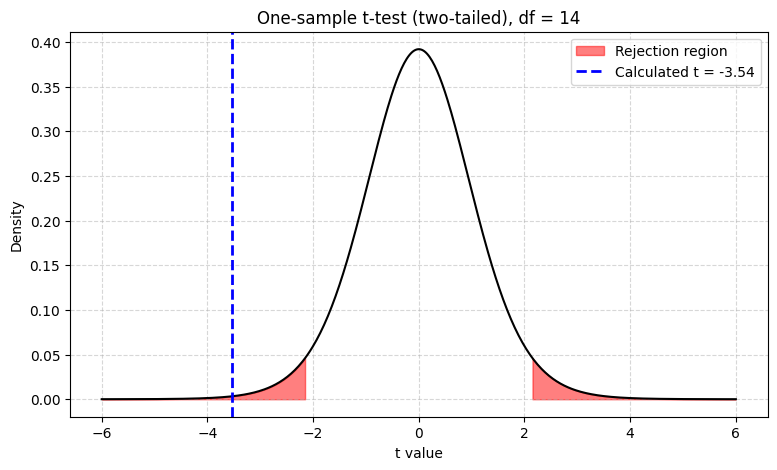

Critical t values: ± 2.1448


In [5]:
# Step 6: Visualize the test on the t-distribution
df = n - 1                                   # degrees of freedom
t_crit = stats.t.ppf(1 - alpha / 2, df)      # critical value for two-tailed test

x = np.linspace(-6, 6, 500)
y = stats.t.pdf(x, df)

plt.figure(figsize=(9, 5))
plt.plot(x, y, color="black")

# rejection regions (both tails)
plt.fill_between(x, y, where=(x <= -t_crit), color="red", alpha=0.5, label="Rejection region")
plt.fill_between(x, y, where=(x >= t_crit), color="red", alpha=0.5)

# our calculated t-statistic
plt.axvline(t_stat, color="blue", linestyle="--", linewidth=2, label=f"Calculated t = {t_stat:.2f}")

plt.title(f"One-sample t-test (two-tailed), df = {df}")
plt.xlabel("t value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print("Critical t values: ±", round(t_crit, 4))

## Example 2: One-tailed test

**Problem:** A teacher claims students score **more than 60 marks** on average after a new teaching method. Marks of 12 students are given. Test at α = 0.05.

- H₀: μ ≤ 60
- H₁: μ > 60 (right-tailed test)

In [6]:
marks = np.array([65, 70, 62, 68, 64, 72, 66, 61, 69, 67, 63, 71])
claimed = 60

print("Sample mean :", round(marks.mean(), 3))

# alternative='greater' makes it a right-tailed test
t_stat2, p_value2 = stats.ttest_1samp(marks, popmean=claimed, alternative="greater")

print("t-statistic :", round(t_stat2, 4))
print("p-value     :", round(p_value2, 6))

if p_value2 <= 0.05:
    print("\nDecision: REJECT H0 -> The average marks are significantly MORE than 60.")
else:
    print("\nDecision: FAIL TO REJECT H0 -> Not enough evidence that average marks exceed 60.")

Sample mean : 66.5
t-statistic : 6.245
p-value     : 3.2e-05

Decision: REJECT H0 -> The average marks are significantly MORE than 60.


## Example 3: Using a different significance level

The same data can give a different decision if α changes. Here we test a **new sample** whose result is "borderline", so we can clearly see how the decision depends on α.

**Problem:** A bulb company claims its bulbs last **1000 hours**. A sample of 10 bulbs is tested.

In [7]:
bulbs = np.array([985, 1010, 970, 990, 1005, 975, 995, 980, 1000, 965])

t_b, p_b = stats.ttest_1samp(bulbs, popmean=1000)
print("Sample mean :", bulbs.mean())
print("t-statistic :", round(t_b, 4))
print(f"p-value     : {p_b:.4f}\n")

for a in [0.10, 0.05, 0.01]:
    decision = "Reject H0" if p_b <= a else "Fail to reject H0"
    print(f"alpha = {a:<5} ->  {decision}")

Sample mean : 987.5
t-statistic : -2.6112
p-value     : 0.0282

alpha = 0.1   ->  Reject H0
alpha = 0.05  ->  Reject H0
alpha = 0.01  ->  Fail to reject H0


## Conclusion

- A **one-sample t-test** was performed using `scipy.stats.ttest_1samp()`.
- **Example 1 (two-tailed):** the sample mean was compared with the claimed mean of 50 hours; the decision was taken by comparing the **p-value with α = 0.05**.
- **Example 2 (one-tailed):** we tested whether the mean is greater than 60 using `alternative="greater"`.
- **Example 3** showed that a borderline result can be rejected at a loose α (0.10) but not at a strict α (0.01). A **smaller p-value** means stronger evidence against H₀, and a stricter (smaller) α makes it harder to reject H₀.